# Predictive Analytics

The descriptive analysis identified historical business patterns, while the diagnostic analysis investigated the factors contributing to those patterns.

The purpose of predictive analytics is to use historical data to estimate future outcomes. These predictions help businesses anticipate future performance, identify potential risks, and support proactive decision-making.

This notebook develops a predictive model using historical sales data and evaluates its ability to estimate future sales performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Profit Margin,Customer Segment Type
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,0.1600,High
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,0.3000,High
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,0.4700,Low
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-0.4000,High
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,0.1125,Low


## Business Objective

The objective of this analysis is to develop a predictive model that estimates sales using historical retail transaction data.

Predicting future sales enables businesses to improve inventory planning, allocate resources more effectively, forecast revenue, and support data-driven decision-making.

For this analysis, Sales is used as the target variable, while Quantity, Discount and Profit are used as predictor variables.

In [3]:
X = df[['Quantity', 'Discount', 'Profit']]

y = df['Sales']

X.head()

,Quantity,Discount,Profit
0,2,0.00,41.9136
1,3,0.00,219.5820
2,2,0.00,6.8714
3,5,0.45,-383.0310
4,2,0.20,2.5164


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 7995
Testing records: 1999


In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = model.predict(X_test)

y_pred[:5]

array([231.03643297, 132.81453205,  91.79859256, 157.77052238,
       146.43691693])

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 245.07556984450287
Mean Squared Error: 680377.4563719595
Root Mean Squared Error: 824.8499599151106
R-squared: -0.15181720106063956


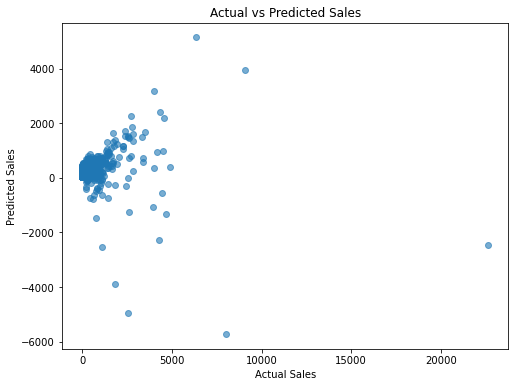

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

In [9]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 245.07556984450287
Mean Squared Error: 680377.4563719595
Root Mean Squared Error: 824.8499599151106
R-squared: -0.15181720106063956


## Improved Predictive Model

The baseline linear regression model did not predict sales accurately, as indicated by its negative R-squared value. To improve predictive performance, additional business variables were included in the model. Categorical variables were also converted into numerical format using one-hot encoding so that they could be used by the regression algorithm.

In [16]:
features = [
    'Quantity',
    'Discount',
    'Profit',
    'Month',
    'Year',
    'Category',
    'Region',
    'Segment'
]

X = df[features]

y = df['Sales']

X.head()

,Quantity,Discount,Profit,Month,Year,Category,Region,Segment
0,2,0.00,41.9136,11,2016,Furniture,South,Consumer
1,3,0.00,219.5820,11,2016,Furniture,South,Consumer
2,2,0.00,6.8714,6,2016,Office Supplies,West,Corporate
3,5,0.45,-383.0310,10,2015,Furniture,South,Consumer
4,2,0.20,2.5164,10,2015,Office Supplies,South,Consumer


In [17]:
X = pd.get_dummies(
    X,
    columns=['Category', 'Region', 'Segment'],
    drop_first=True
)

X.head()

,Quantity,Discount,Profit,Month,Year,Category_Office Supplies,Category_Technology,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office
0,2,0.00,41.9136,11,2016,0,0,0,1,0,0,0
1,3,0.00,219.5820,11,2016,0,0,0,1,0,0,0
2,2,0.00,6.8714,6,2016,1,0,0,0,1,1,0
3,5,0.45,-383.0310,10,2015,0,0,0,1,0,0,0
4,2,0.20,2.5164,10,2015,1,0,0,1,0,0,0


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 7995
Testing records: 1999


In [19]:
model_improved = LinearRegression()

model_improved.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred_improved = model_improved.predict(X_test)

y_pred_improved[:5]

array([136.93939178,  39.95535915, 223.10790016, 294.98009202,
       284.77167256])

In [21]:
mae_improved = mean_absolute_error(y_test, y_pred_improved)
mse_improved = mean_squared_error(y_test, y_pred_improved)
rmse_improved = mse_improved ** 0.5
r2_improved = r2_score(y_test, y_pred_improved)

print("Mean Absolute Error:", mae_improved)
print("Mean Squared Error:", mse_improved)
print("Root Mean Squared Error:", rmse_improved)
print("R-squared:", r2_improved)

Mean Absolute Error: 225.51017830990543
Mean Squared Error: 654080.7787378539
Root Mean Squared Error: 808.7526066343489
R-squared: -0.10729931566328665


## Model Evaluation

The improved linear regression model achieved a lower Mean Absolute Error (225.51) and Root Mean Squared Error (808.75) than the baseline model, indicating a modest improvement in prediction accuracy.

The R-squared value improved from -0.1518 to -0.1073 after incorporating additional numerical and categorical features. Although this represents an improvement over the baseline model, the negative R-squared value indicates that the model does not explain the variation in sales sufficiently well for reliable prediction.

These results suggest that sales are influenced by factors beyond those included in the model. More advanced predictive techniques or additional business variables may be required to improve forecasting performance.

## Business Interpretation

The predictive models demonstrated that historical transaction data can be used to estimate future sales, although the accuracy of the linear regression models was limited.

The improved model performed better than the baseline after additional business variables were included, showing that factors such as product category, region and customer segment contribute to sales performance. However, the negative R-squared value indicates that sales are influenced by additional factors that were not included in the model.

From a business perspective, these findings highlight that sales forecasting is a complex task and that businesses should consider a wider range of variables when developing predictive models for operational planning and strategic decision-making.

## Business Recommendations

Based on the predictive analysis, the business should continue collecting high-quality historical sales data and consider incorporating additional variables such as promotional campaigns, product pricing, customer purchasing behaviour and external market conditions into future predictive models.

More advanced machine learning algorithms, including Decision Trees, Random Forests or Gradient Boosting models, may improve prediction accuracy by capturing more complex relationships within the data.

Improving predictive accuracy would enable the business to make more reliable forecasts, optimise inventory levels, allocate resources more effectively and support data-driven planning.

# Predictive Analytics Summary

The objective of this notebook was to develop predictive models capable of estimating future sales using historical retail transaction data.

A baseline linear regression model was first developed using a limited set of numerical features. After evaluating its performance, an improved model was created by incorporating additional business variables and categorical information through one-hot encoding.

Although the improved model achieved lower prediction errors than the baseline, its overall predictive performance remained limited. This demonstrates that sales forecasting is influenced by numerous business factors that extend beyond the variables available in the dataset.

Despite these limitations, the predictive analysis illustrates the complete predictive modelling process, including data preparation, model development, evaluation, model improvement and interpretation. The insights gained from this analysis provide a foundation for the final phase of the project, where prescriptive analytics will be used to develop actionable business recommendations.